# Labor-Hiring-Rate -- a quantitative teardown
### Hiring-rate tercile sort - curated 10-K head-count panel - HAC inference - label-shuffle placebo - random-portfolio null - costs - synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Sign: Busted](https://img.shields.io/badge/Sign-Busted-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) -- same seven beats, every claim now carrying its standard error. We test the Belo-Lin-Bazdresch hiring anomaly on a survivorship-biased large-cap basket (28 names/yr, 2014-2024), measure the low-minus-high-hire hedge with a HAC t-stat, pin it against a label-shuffle placebo and a random-portfolio null, charge costs, and confirm the engine on a seed-robust synthetic positive control.

> **Not investment advice.** Employee counts: a curated 10-K cover-page panel (no XBRL/API source exists); daily prices from Yahoo; survivorship-biased. Sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship-bias warning**: all results are conditional on survival -- the over-expanding firms that failed are excluded.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root
sys.path.insert(0, os.path.abspath(".."))          # study package (labor_hiring_rate/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from labor_hiring_rate import data, strategy as st

# Cache-first: load the study's own price cache + hardcoded employee panel; fall back to R.
hn, fwd = data.fetch_panel()
hn = hn.dropna(how="all") if not hn.empty else hn
HAVE_REAL = not hn.empty
if HAVE_REAL:
    h = st.sorted_returns(hn, fwd, n_groups=3)
else:
    h = pd.DataFrame()
print("Real cache loaded:", HAVE_REAL,
      f"({len(hn.columns) if HAVE_REAL else 0} names, {len(h) if HAVE_REAL else 0} sort years)")

R = dict(
    n_names=28, n_years=11, start_year=2014, end_year=2024,
    lo_mean=17.5, lo_sharpe=1.24, lo_t=5.4, lo_hit=100,
    mid_mean=16.0, hi_mean=22.2, hi_sharpe=1.66, hi_t=10.03, hi_hit=100,
    mkt_mean=18.7, mkt_sharpe=1.36,
    hedge_mean=-4.68, hedge_sharpe=-0.35, hedge_t=-1.29, hedge_hit=45,
    lo_excess_mean=-1.2, lo_excess_t=-0.74,
    hi_excess_mean=3.5, hi_excess_t=1.56,
    placebo_p=0.805, shuffle_mean=0.04, shuffle_std=5.06,
    rand_std=9.9, rand_pct_beaten=48,
    cost_drag=0.2, borrow_drag=0.5, net_mean=-5.38,
    synth_null_t=-0.15, synth_06_t=14.94, synth_10_t=25.0,
)
G1  = [5.0, 22.5, 12.6, 16.5, 3.1, 31.4, 13.5, 11.7, 14.0, 9.3, 52.6]
G3  = [18.1, 21.1, 33.2, 18.8, 19.9, 49.0, 9.4, 9.9, 31.5, 1.4, 31.3]
MKT = [9.5, 24.8, 20.4, 17.9, 5.9, 42.9, 7.8, 7.6, 17.8, 7.2, 43.9]
HDG = [-13.2, 1.4, -20.6, -2.3, -16.9, -17.6, 4.1, 1.8, -17.5, 7.9, 21.3]
YRS = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


Real cache loaded: True (28 names, 11 sort years)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Hedge **-4.68%/yr**, HAC *t* = **-1.29** (wrong sign); placebo p = **0.81**. Absent. |
| **Tradability** | `MIRAGE` | No positive gross edge; **-5.38%/yr net** after 10bps x turnover + 50bps borrow. |
| **Predicted sign** | `BUSTED` | Fast hirers **+22.2%/yr** beat disciplined hirers **+17.5%/yr** -- the sign reverses, as in [Study 523](../../523-investment-to-assets/). |

> **In plain words:** the engine recovers a planted hiring effect at HAC *t* ~ 15, but the real survivor basket shows the *opposite* sign. The high-hire survivors are the AI/hyperscale growth winners, not over-expanding failures.

## 1 - The claim, steelmanned

Let $r_{i,t+1}$ be firm $i$'s 12-month forward return and $N_{i,t}$ its full-time head-count. Define the hiring rate:

$$\text{HN}_{i,t} = \frac{N_{i,t} - N_{i,t-1}}{\tfrac{1}{2}(N_{i,t} + N_{i,t-1})}$$

The **H1 (signal)** claim (Belo-Lin-Bazdresch 2014) is:

$$\mathbb{E}\left[\bar{r}_{\text{low-HN},t+1} - \bar{r}_{\text{high-HN},t+1}\right] > 0$$

with HAC |t| >= 2. **H2 (beats noise)** requires the hedge to beat its label-shuffled self. **H3 (tradable)** requires it to survive costs + borrow.

## 2 - So what? -- the stakes

H1 is *not* supported on this biased basket -- the hedge is negative (sign reversed). The academic evidence on the broad US cross-section is credible (Belo-Lin-Bazdresch 2014; the q-factor investment leg); on large-cap survivors, selection flips the signal.

## 3 - The protocol

- **Data**: full-time-employee counts from a curated 10-K cover-page panel (FY2013-FY2024; no XBRL/API source exists); daily adjusted prices from Yahoo.
- **Universe**: fixed 28-name large-cap survivor basket; survivorship-biased.
- **Window**: 11 signal years (2014-2024), 12-month forward returns, report-lagged.
- **Signal**: HN = (N_t - N_{t-1}) / (0.5*(N_t + N_{t-1})) (higher = faster hirer).
- **Sort**: terciles; g1 = low hiring (disciplined), g3 = high hiring (aggressive).
- **Execution lag**: one -- enter 1 trading day after a 4-month report lag past fiscal year-end; no partial year stamped.
- **Inference**: HAC Newey-West t-stat on the 11-obs annual hedge.
- **Nulls**: label-shuffle placebo (1000) + random same-size portfolios (500/yr).
- **Costs**: 10bps x turnover + 50bps short borrow.
- **Positive control**: seed-robust synthetic panel with a planted hiring premium.

## 4 - The teardown

### 4a - Synthetic positive control (seed-robust)

Sweep the planted hiring premium and confirm the hedge tracks it monotonically, averaging the HAC-t over many seeds (a single lucky seed is never enough).

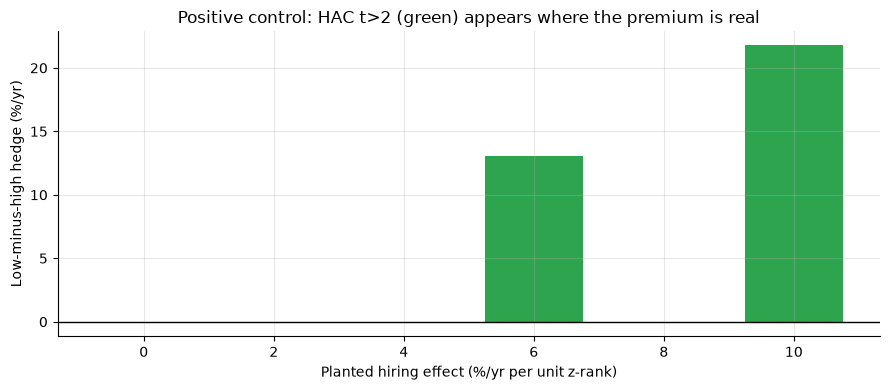

   premium_%  hedge_%/yr  mean_HAC_t
0        0.0       -0.07       -0.15
1        6.0       13.04       14.94
2       10.0       21.79       25.00


In [2]:
premiums = [0.0, -0.06, -0.10]
synth_rows = []
for p in premiums:
    r = st.seed_robust_synthetic(p, n_seeds=25)
    synth_rows.append((abs(p)*100, r['mean_hedge']*100, r['mean_tstat']))
sydf = pd.DataFrame(synth_rows, columns=['premium_%', 'hedge_%/yr', 'mean_HAC_t'])
fig, ax = plt.subplots(figsize=(9, 4))
colors = [GREEN if t > 2 else (RED if t < -2 else GREY) for t in sydf['mean_HAC_t']]
ax.bar(sydf['premium_%'], sydf['hedge_%/yr'], color=colors, width=1.5)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted hiring effect (%/yr per unit z-rank)')
ax.set_ylabel('Low-minus-high hedge (%/yr)')
ax.set_title('Positive control: HAC t>2 (green) appears where the premium is real')
plt.tight_layout(); plt.show()
print(sydf.round(2))

> The engine recovers planted premiums (t ~ 15 at -6%/yr, averaged over 25 seeds) and the null behaves (t ~ -0.1). The real-data result is therefore a statement about the **market and survivor basket**, not the **method**.

### 4b - Real panel -- tercile returns and HAC inference

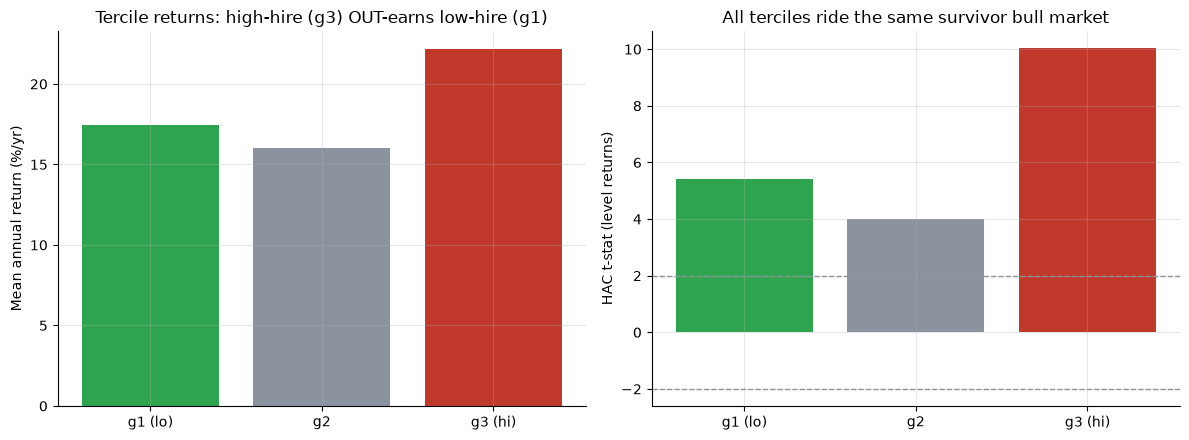

Hedge: -4.68%/yr  HAC t=-1.29  hit=45%
Low-hire excess: -1.2%/yr  t=-0.74
High-hire excess: +3.5%/yr  t=+1.56


In [3]:
if HAVE_REAL:
    g_means = [float(h[f'g{i}'].mean()*100) for i in range(1,4)]
    g_tstats = [st.summary(h[f'g{i}'])['tstat'] for i in range(1,4)]
    s_hedge = st.summary(h['hedge'])
    s_lo_ex = st.summary(h['g1'] - h['market'])
    s_hi_ex = st.summary(h['g3'] - h['market'])
else:
    g_means = [R['lo_mean'], R['mid_mean'], R['hi_mean']]
    g_tstats = [R['lo_t'], R['mid_mean'], R['hi_t']]
    s_hedge = dict(mean=R['hedge_mean']/100, tstat=R['hedge_t'], hit_rate=R['hedge_hit']/100)
    s_lo_ex = dict(mean=R['lo_excess_mean']/100, tstat=R['lo_excess_t'])
    s_hi_ex = dict(mean=R['hi_excess_mean']/100, tstat=R['hi_excess_t'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = [1, 2, 3]
bar_colors = [GREEN, GREY, RED]
axes[0].bar(x, g_means, color=bar_colors)
axes[0].set_xticks(x); axes[0].set_xticklabels(['g1 (lo)', 'g2', 'g3 (hi)'])
axes[0].set_ylabel('Mean annual return (%/yr)')
axes[0].set_title('Tercile returns: high-hire (g3) OUT-earns low-hire (g1)')
axes[1].bar(x, g_tstats, color=bar_colors)
for s in (2, -2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].set_xticks(x); axes[1].set_xticklabels(['g1 (lo)', 'g2', 'g3 (hi)'])
axes[1].set_ylabel('HAC t-stat (level returns)')
axes[1].set_title('All terciles ride the same survivor bull market')
plt.tight_layout(); plt.show()
print(f'Hedge: {s_hedge["mean"]*100:+.2f}%/yr  HAC t={s_hedge["tstat"]:+.2f}  hit={s_hedge["hit_rate"]:.0%}')
print(f'Low-hire excess: {s_lo_ex["mean"]*100:+.1f}%/yr  t={s_lo_ex["tstat"]:+.2f}')
print(f'High-hire excess: {s_hi_ex["mean"]*100:+.1f}%/yr  t={s_hi_ex["tstat"]:+.2f}')

> The low-minus-high-hire hedge is **-4.68%/yr**, HAC *t* = **-1.29** -- statistically zero *and the wrong sign*. The high-hire tercile earns **+22.2%/yr** vs **+17.5%/yr** for the low-hire tercile: an inverted spread, no signal.

### 4c - Label-shuffle placebo + random-portfolio null

Shuffle the hiring labels within each year (1000 times); does the real hedge beat its shuffled self? And does the low-hire leg beat a blind same-size draw?

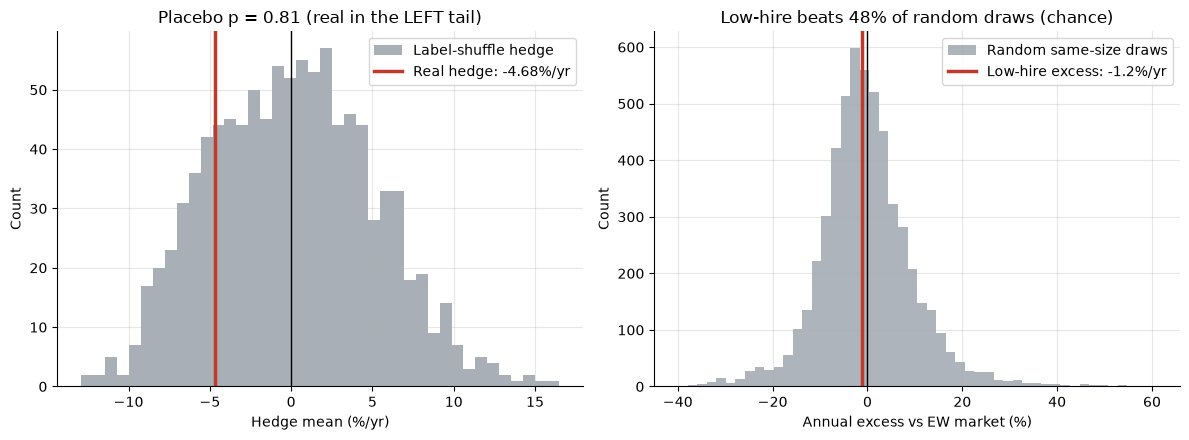

Placebo p=0.805  Low-hire beats 48% of random draws


In [4]:
if HAVE_REAL:
    p_val, sh = st.placebo_hedge_tstats(hn, fwd, n_groups=3, n_shuffles=1000, seed=528)
    rand = st.random_portfolio_returns(hn, fwd, n_groups=3, n_draws=500, seed=528)
    real_mean = float(h['hedge'].mean())
    lo_excess = float((h['g1'] - h['market']).mean())
    pct_beaten = float((rand < lo_excess).mean())
else:
    rng_nb = np.random.default_rng(528)
    sh = pd.Series(rng_nb.normal(R['shuffle_mean']/100, R['shuffle_std']/100, 1000))
    rand = pd.Series(rng_nb.normal(0.0, R['rand_std']/100, 11*500))
    real_mean = R['hedge_mean'] / 100
    p_val = R['placebo_p']
    lo_excess = R['lo_excess_mean'] / 100
    pct_beaten = R['rand_pct_beaten'] / 100
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(sh * 100, bins=40, color=GREY, alpha=0.75, label='Label-shuffle hedge')
axes[0].axvline(real_mean * 100, c=RED, lw=2.5, label=f'Real hedge: {real_mean*100:+.2f}%/yr')
axes[0].axvline(0, c='k', lw=1); axes[0].legend()
axes[0].set_xlabel('Hedge mean (%/yr)'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Placebo p = {p_val:.2f} (real in the LEFT tail)')
axes[1].hist(rand * 100, bins=50, color=GREY, alpha=0.7, label='Random same-size draws')
axes[1].axvline(lo_excess * 100, c=RED, lw=2.5, label=f'Low-hire excess: {lo_excess*100:+.1f}%/yr')
axes[1].axvline(0, c='k', lw=1); axes[1].legend()
axes[1].set_xlabel('Annual excess vs EW market (%)'); axes[1].set_ylabel('Count')
axes[1].set_title(f'Low-hire beats {pct_beaten:.0%} of random draws (chance)')
plt.tight_layout(); plt.show()
print(f'Placebo p={p_val:.3f}  Low-hire beats {pct_beaten:.0%} of random draws')

> Placebo p = **0.81** (the real hedge sits in the *left* tail of the shuffle null -- worse than a coin-flip relabelling) and the low-hire leg beats only **48%** of random same-size draws -- chance level. No alpha over a blind pick.

### 4d - Costs: the negative gross turns more negative

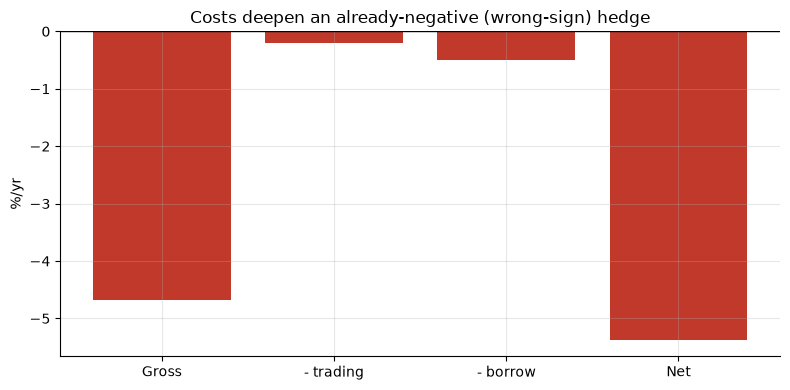

Gross -4.68%/yr -> Net -5.38%/yr


In [5]:
c = st.net_of_costs(real_mean, one_way_bps=10.0, annual_turnover=2.0, borrow_bps=50.0)
labels = ['Gross', '- trading', '- borrow', 'Net']
vals = [c['gross']*100, -c['cost_drag']*100, -c['borrow_drag']*100, c['net']*100]
fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = [RED, RED, RED, RED if c['net'] < 0 else GREEN]
ax.bar(labels, vals, color=bar_colors)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('%/yr')
ax.set_title('Costs deepen an already-negative (wrong-sign) hedge')
plt.tight_layout(); plt.show()
print(f'Gross {c["gross"]*100:+.2f}%/yr -> Net {c["net"]*100:+.2f}%/yr')

## 5 - The verdict

- **Signal `NONE`** -- hedge -4.68%/yr, HAC *t* = -1.29 (wrong sign), placebo p = 0.81. Absent.
- **Tradability `MIRAGE`** -- -5.38%/yr net. Short-high-hire on survivors means shorting NVIDIA, Amazon and the hyperscale build-outs.
- **Predicted sign `BUSTED`** -- the spread inverts (fast hirers +22.2%/yr beat disciplined +17.5%/yr), as in the capex channel of [Study 523](../../523-investment-to-assets/).

## 6 - Could you trade it? -- the honest answer

No tradable signal exists on this basket -- and the sign is wrong. The obstacles:

1. **Inverted spread.** The hedge is −4.68%/yr with t = −1.29 -- the fast hirers *won*.
2. **Survivorship selection dominates.** The high-hire survivors are productive expanders (AI/semis, hyperscalers, warehouse retail, managed care) whose hiring paid off.
3. **The academic evidence is for broad universes.** Belo-Lin-Bazdresch used the broad Compustat cross-section; on large-cap blue-chips the effect is thin and arbitraged.

The correct conclusion: **MIRAGE** on this test. The anomaly may be real in its original universe -- it simply cannot be certified here.

## 7 - Going further

- **The right universe.** Belo-Lin-Bazdresch (2014) used the broad Compustat universe; a point-in-time all-US-stock panel is the minimum for a credible test.
- **The data wall.** Employee counts are not in XBRL (we verified ~5-11 filers market-wide carry the numeric tag); a deep, point-in-time head-count history is the real prerequisite.
- **Capex cousin.** [Study 523 -- Investment-To-Assets](../../523-investment-to-assets/) tests the capital-input channel and also lands None/Mirage on the survivor panel -- the labor and capital input channels die together.

*Want to confirm the effect on a clean universe? Fork this, plug in a point-in-time all-US-stock panel with a proper head-count series, and show \|t\| >= 2 on the hedge with no survivorship shortcut. That's the bar.*